# Phase 4.2: Two-Tower Neural Network (Week 10)

Build and train two-tower neural network for user-destination matching.

In [16]:
import sys
sys.path.insert(0, '../../')

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import joblib
from pathlib import Path
from config import *
from src.models.two_tower import TwoTowerRecommender, RecommendationDataset, TwoTowerTrainer
from torch.utils.data import DataLoader

print("="*70)
print("PHASE 4b: Two-Tower Neural Network Model")
print("="*70)

PHASE 4b: Two-Tower Neural Network Model


In [15]:
print("\n[6/6] Saving model and results...")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

# Save model
model_path = OUTPUT_DIR / 'two_tower_model.pt'
torch.save(model.state_dict(), model_path)
print(f"  ✓ Model saved to {model_path}")

# Save trainer state
trainer_path = OUTPUT_DIR / 'two_tower_trainer.joblib'
joblib.dump(trainer, trainer_path)
print(f"  ✓ Trainer saved to {trainer_path}")

# Save results
results = {
    'mse': float(mse),
    'mae': float(mae),
    'r2': float(r2),
    'epochs_trained': len(history['train_loss']),
    'user_input_dim': user_input_dim,
    'dest_input_dim': dest_input_dim,
    'embedding_dim': 64,
    'hidden_dim': 128,
    'n_train_samples': len(train_dataset),
    'n_test_samples': len(test_dataset)
}

results_path = REPORT_DIR / 'phase4b_two_tower_results.txt'
with open(results_path, 'w') as f:
    f.write("PHASE 4b: Two-Tower Neural Network Results\n")
    f.write("="*50 + "\n")
    for k, v in results.items():
        f.write(f"{k:20s}: {v}\n")

print(f"  ✓ Results saved to {results_path}")

print(f"\n{'='*70}")
print("✅ PHASE 4b COMPLETE: Two-Tower Neural Network")
print(f"{'='*70}")


[6/6] Saving model and results...
  ✓ Model saved to C:\Users\Marlene\OneDrive\Desktop\[Tume] ML course\ML Project\outputs\two_tower_model.pt
  ✓ Trainer saved to C:\Users\Marlene\OneDrive\Desktop\[Tume] ML course\ML Project\outputs\two_tower_trainer.joblib
  ✓ Results saved to C:\Users\Marlene\OneDrive\Desktop\[Tume] ML course\ML Project\reports\phase4b_two_tower_results.txt

✅ PHASE 4b COMPLETE: Two-Tower Neural Network


## Step 6: Save Model and Results


[5/6] Evaluating on test set...

TWO-TOWER RESULTS
Mean Squared Error (MSE):  5.9275
Mean Absolute Error (MAE): 2.0678
R² Score:                  -5.2534


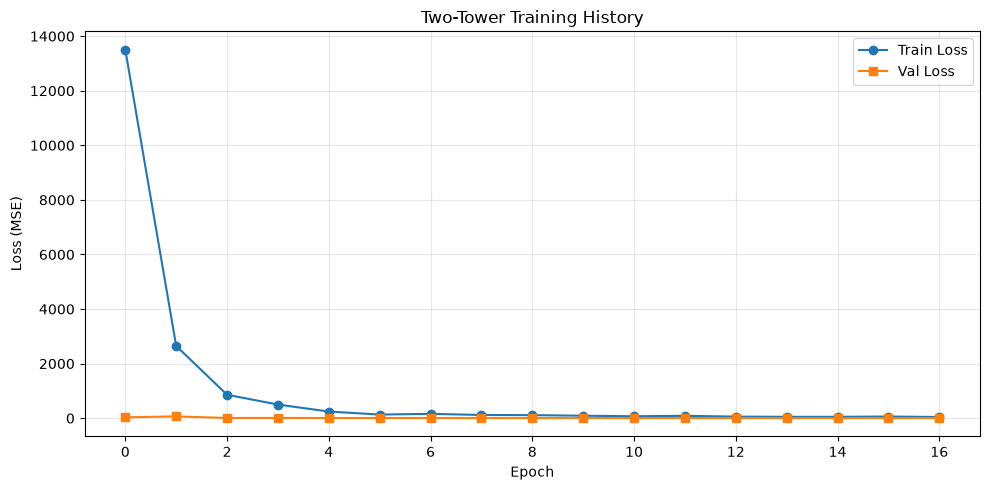

In [14]:
print("\n[5/6] Evaluating on test set...")

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Get predictions
y_pred = trainer.predict(test_loader)

# Compute metrics
mse = mean_squared_error(test_ratings, y_pred)
mae = mean_absolute_error(test_ratings, y_pred)
r2 = r2_score(test_ratings, y_pred)

print(f"\n{'='*70}")
print("TWO-TOWER RESULTS")
print(f"{'='*70}")
print(f"Mean Squared Error (MSE):  {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R² Score:                  {r2:.4f}")
print(f"{'='*70}")

# Plot training history
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(history['train_loss'], label='Train Loss', marker='o')
plt.plot(history['val_loss'], label='Val Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Two-Tower Training History')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 5: Evaluate Model

In [13]:
print("\n[4/6] Training Two-Tower model...")

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"  Using device: {device}")

# Initialize model
user_input_dim = train_user_features.shape[1]
dest_input_dim = train_dest_features.shape[1]

model = TwoTowerRecommender(
    user_input_dim=user_input_dim,
    dest_input_dim=dest_input_dim,
    hidden_dim=128,
    embedding_dim=64
)

# Initialize trainer
trainer = TwoTowerTrainer(model, device=device, learning_rate=0.001)

# Train model
print(f"  Training on {user_input_dim} user features + {dest_input_dim} dest features...")
history = trainer.train(train_loader, test_loader, epochs=20, early_stopping_patience=5)

print(f"  ✓ Model trained")
print(f"  ✓ Final train loss: {history['train_loss'][-1]:.4f}")
print(f"  ✓ Final val loss: {history['val_loss'][-1]:.4f}")


[4/6] Training Two-Tower model...
  Using device: cpu
  Training on 4 user features + 32 dest features...
Epoch 1/20 - Train: 13502.3898, Val: 32.1841
Epoch 2/20 - Train: 2646.2491, Val: 65.4484
Epoch 3/20 - Train: 858.6779, Val: 8.6158
Epoch 4/20 - Train: 499.7378, Val: 9.7447
Epoch 5/20 - Train: 243.9362, Val: 6.8524
Epoch 6/20 - Train: 132.8820, Val: 5.7508
Epoch 7/20 - Train: 158.7985, Val: 5.2033
Epoch 8/20 - Train: 118.8586, Val: 4.8771
Epoch 9/20 - Train: 111.8342, Val: 4.8109
Epoch 10/20 - Train: 90.5707, Val: 4.6720
Epoch 11/20 - Train: 71.0452, Val: 4.2933
Epoch 12/20 - Train: 87.7950, Val: 4.2751
Epoch 13/20 - Train: 57.6740, Val: 4.6539
Epoch 14/20 - Train: 49.9769, Val: 4.9215
Epoch 15/20 - Train: 50.3507, Val: 5.1189
Epoch 16/20 - Train: 61.3526, Val: 5.5257
Epoch 17/20 - Train: 42.5173, Val: 6.1577
Early stopping at epoch 17
  ✓ Model trained
  ✓ Final train loss: 42.5173
  ✓ Final val loss: 6.1577


## Step 4: Train Two-Tower Model

In [12]:
print("\n[3/6] Creating datasets...")

# Prepare training data
train_user_features = []
train_dest_features = []
train_ratings = []

for idx, row in train_reviews_with_city.iterrows():
    user_id = row['user_id']
    city = row['city']
    rating = row['stars']
    
    if user_id in user_features_dict and city in dest_features_dict:
        train_user_features.append(user_features_dict[user_id])
        train_dest_features.append(dest_features_dict[city])
        train_ratings.append(rating)

# Prepare test data
test_user_features = []
test_dest_features = []
test_ratings = []

for idx, row in test_reviews_with_city.iterrows():
    user_id = row['user_id']
    city = row['city']
    rating = row['stars']
    
    # Use default features for unseen users
    if user_id not in user_features_dict:
        user_feat = np.array([3.5, 1.0, 1.0, 1.0], dtype=np.float32)
    else:
        user_feat = user_features_dict[user_id]
    
    if city in dest_features_dict:
        test_user_features.append(user_feat)
        test_dest_features.append(dest_features_dict[city])
        test_ratings.append(rating)

# Convert to arrays
train_user_features = np.array(train_user_features, dtype=np.float32)
train_dest_features = np.array(train_dest_features, dtype=np.float32)
train_ratings = np.array(train_ratings, dtype=np.float32)

test_user_features = np.array(test_user_features, dtype=np.float32)
test_dest_features = np.array(test_dest_features, dtype=np.float32)
test_ratings = np.array(test_ratings, dtype=np.float32)

# Create datasets
train_dataset = RecommendationDataset(train_user_features, train_dest_features, train_ratings)
test_dataset = RecommendationDataset(test_user_features, test_dest_features, test_ratings)

# Create dataloaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"  ✓ Train samples: {len(train_dataset)}")
print(f"  ✓ Test samples: {len(test_dataset)}")
print(f"  ✓ Batch size: {batch_size}")


[3/6] Creating datasets...
  ✓ Train samples: 221
  ✓ Test samples: 77
  ✓ Batch size: 32


## Step 3: Create Training Datasets

In [11]:
print("\n[2/6] Building feature matrices...")

# Build user features
user_features_dict = {}
for user_id in train_reviews_with_city['user_id'].unique():
    user_reviews = train_reviews_with_city[train_reviews_with_city['user_id'] == user_id]
    user_feat = np.array([
        user_reviews['stars'].mean(),
        user_reviews['stars'].std() or 0,
        len(user_reviews),
        user_reviews['city'].nunique()
    ], dtype=np.float32)
    user_features_dict[user_id] = user_feat

# Build destination features (basic + weather)
dest_features_dict = {}
weather_cols = [col for col in weather_features.columns if col != 'city']

for city in businesses['city'].unique():
    city_reviews = train_reviews_with_city[train_reviews_with_city['city'] == city]
    weather_row = weather_features[weather_features['city'] == city]
    
    dest_feat = [
        city_reviews['stars'].mean() if len(city_reviews) > 0 else 3.5,
        len(city_reviews),
        len(businesses[businesses['city'] == city])
    ]
    
    # Add weather features
    if not weather_row.empty:
        dest_feat.extend(weather_row[weather_cols].values[0].tolist())
    else:
        dest_feat.extend([0] * len(weather_cols))
    
    dest_features_dict[city] = np.array(dest_feat, dtype=np.float32)

print(f"  ✓ User features: {len(user_features_dict)} users")
print(f"  ✓ Destination features: {len(dest_features_dict)} cities")
print(f"  ✓ User feature dim: {list(user_features_dict.values())[0].shape[0]}")
print(f"  ✓ Dest feature dim: {list(dest_features_dict.values())[0].shape[0]}")


[2/6] Building feature matrices...
  ✓ User features: 18 users
  ✓ Destination features: 39 cities
  ✓ User feature dim: 4
  ✓ Dest feature dim: 32


## Step 2: Build Feature Matrices

In [9]:
print("\n[1/6] Loading cached data...")

# Load reviews and businesses
train_reviews = pd.read_parquet(CACHE_DIR / 'train_reviews.parquet')
test_reviews = pd.read_parquet(CACHE_DIR / 'test_reviews.parquet')
businesses = pd.read_parquet(CACHE_DIR / 'businesses_major_cities.parquet')

# Load weather features
weather_features = pd.read_parquet(CACHE_DIR / 'weather_features_for_models.parquet')

# Load embeddings
dest_embeddings = joblib.load(CACHE_DIR / 'destination_embeddings.joblib')
user_embeddings = joblib.load(CACHE_DIR / 'user_embeddings.joblib')

print(f"  ✓ Train reviews: {len(train_reviews):,}")
print(f"  ✓ Test reviews: {len(test_reviews):,}")
print(f"  ✓ Businesses: {len(businesses):,}")
print(f"  ✓ Embeddings loaded")

# Merge with city info
train_reviews_with_city = train_reviews.merge(
    businesses[['business_id', 'city']], on='business_id', how='left'
)
test_reviews_with_city = test_reviews.merge(
    businesses[['business_id', 'city']], on='business_id', how='left'
)


[1/6] Loading cached data...
  ✓ Train reviews: 221
  ✓ Test reviews: 77
  ✓ Businesses: 10,341
  ✓ Embeddings loaded


## Step 1: Load Cached Data